# MLOps Training 2026/2027 — Task 2
## Notebook 2 — Data Labeling & Target Definition

### Objective
In this notebook, we define and construct the target variable **`is_late`** for each order.
An order is considered late (`is_late = 1`) if the actual customer delivery date exceeds the estimated delivery date; otherwise, it is on time (`is_late = 0`).

We also analyze class imbalance and save the clean labeled dataset as an artifact for downstream modeling.

### Input Artifact
- `artifacts/notebook_01/olist_ml_table.parquet`

### Output Artifact
- `artifacts/notebook_02/olist_labeled_table.parquet`

## 1. Import Libraries & Configure Paths

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Dynamic project paths for portability
artifact_dir = Path.cwd() / "artifacts" / "notebook_02"
artifact_dir.mkdir(parents=True, exist_ok=True)

input_path = Path.cwd() / "artifacts" / "notebook_01" / "olist_ml_table.parquet"
print("Input artifact path:", input_path.resolve())
print("Output artifact dir:", artifact_dir.resolve())

Input artifact path: /Users/ouahibaahmid/training mlops/artifacts/notebook_01/olist_ml_table.parquet
Output artifact dir: /Users/ouahibaahmid/training mlops/artifacts/notebook_02


## 2. Load ML Table Artifact from Notebook 1

In [2]:
ml_table = pd.read_parquet(input_path)

print(f"✓ Loaded ML table: {input_path.name}")
print(f"Rows: {len(ml_table):,}")
print(f"Columns: {len(ml_table.columns)}")
print("\nColumns:", ml_table.columns.tolist())

✓ Loaded ML table: olist_ml_table.parquet
Rows: 99,441
Columns: 26

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'item_count', 'unique_products', 'unique_sellers', 'total_item_value', 'total_freight_value', 'payment_count', 'total_payment_value', 'max_payment_installments', 'review_count', 'average_review_score', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'distance_km']


## 3. Parse Delivery Timestamps

We parse `order_delivered_customer_date` and `order_estimated_delivery_date` into datetime objects.

In [3]:
date_columns = [
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    ml_table[col] = pd.to_datetime(
        ml_table[col],
        errors="coerce"
    )

print(ml_table[date_columns].dtypes)
print("\nMissing delivery dates:")
print(ml_table[date_columns].isna().sum())

order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing delivery dates:
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


## 4. Filter Orders with Valid Delivery Dates

To determine ground truth delivery performance, we filter for delivered orders that have both the actual delivery timestamp and the estimated delivery timestamp.

In [4]:
has_both_dates = (
    ml_table["order_delivered_customer_date"].notna()
    & ml_table["order_estimated_delivery_date"].notna()
)

print(f"Orders with both dates: {has_both_dates.sum():,}")
print(f"Orders missing delivery dates: {(~has_both_dates).sum():,}")

labeled_table = ml_table.loc[has_both_dates].copy()
print(f"Labeled dataset size: {len(labeled_table):,} rows")

Orders with both dates: 96,476
Orders missing delivery dates: 2,965
Labeled dataset size: 96,476 rows


## 5. Construct the Target Label (`is_late`) and Delivery Delay

- `delivery_delay_days`: Number of days between actual delivery date and estimated delivery date.
- `is_late`: Binary target flag (1 if delivered after estimated date, 0 otherwise).

In [5]:
# Calculate delivery delay in days
labeled_table["delivery_delay_days"] = (
    labeled_table["order_delivered_customer_date"]
    - labeled_table["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

labeled_table["delivery_delay_days"] = labeled_table["delivery_delay_days"].round(2)

# Create binary target
labeled_table["is_late"] = (
    labeled_table["delivery_delay_days"] > 0
).astype("int8")

print("✓ Target column 'is_late' created.")
print("\nClass counts:")
print(labeled_table["is_late"].value_counts())

✓ Target column 'is_late' created.

Class counts:
is_late
0    88655
1     7821
Name: count, dtype: int64


## 6. Validate Target Logic with Sanity Samples

In [6]:
sample_orders = labeled_table[
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_delay_days",
        "is_late"
    ]
].sample(n=min(10, len(labeled_table)), random_state=42)

print(sample_orders)

# Sanity assertion
label_check = (labeled_table["delivery_delay_days"] > 0).astype("int8")
assert (label_check == labeled_table["is_late"]).all()
print("✓ Sanity assertion passed: 'is_late' strictly matches delivery_delay_days > 0.")

                               order_id order_delivered_customer_date  \
22500  c58cff333993bb6b7161d7ec1350eef3           2018-04-06 02:32:49   
68941  87673b5ccb20de0a91c28cc461105d76           2018-05-23 15:28:28   
23988  80b430d0029bb33110ac31d60e87e0b8           2017-12-07 18:43:46   
31303  580603672a21252f21fa8a8b4ca85986           2018-04-26 17:44:27   
36131  c09f32e7ba9b4a134455b36eeff8fff3           2018-04-13 17:32:07   
58330  462240cb1ec4e5db517e73fff57ebfc0           2017-12-14 18:56:14   
95960  5bc2a7b8f0817443a86b69461e742cc9           2018-01-12 21:59:18   
56131  4ef8f514f95bb0a41f58965ea04e7027           2017-05-26 15:59:47   
56750  587904dc1c873ebfb6078160b4819d8e           2017-12-06 19:43:34   
92212  29c3b79aace1b72a82b1232bf494e16f           2018-04-28 15:51:50   

      order_estimated_delivery_date  delivery_delay_days  is_late  
22500                    2018-04-18               -11.89        0  
68941                    2018-05-30                -6.36    

## 7. Class Imbalance Analysis

We compute the ratio between on-time (majority) and late (minority) classes to guide evaluation metric choices and model weighting.

In [7]:
class_counts = labeled_table["is_late"].value_counts().sort_index()
class_counts.index = ["On time (0)", "Late (1)"]

class_distribution = (
    labeled_table["is_late"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)
class_distribution.index = ["On time (0)", "Late (1)"]

distribution_df = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_distribution.round(2)
})

print(distribution_df)

majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count
minority_pct = minority_count / (majority_count + minority_count) * 100

print(f"Majority class: {majority_count:,}")
print(f"Minority class: {minority_count:,}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Minority class percentage: {minority_pct:.2f}%")

             Count  Percentage (%)
On time (0)  88655           91.89
Late (1)      7821            8.11
Majority class: 88,655
Minority class: 7,821
Imbalance ratio: 11.34:1
Minority class percentage: 8.11%


## 8. Visualize Class Distribution

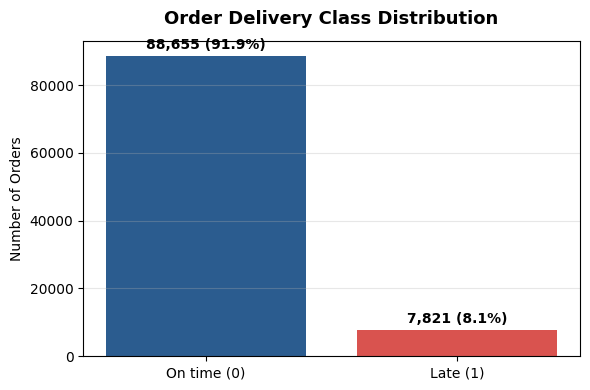

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["On time (0)", "Late (1)"], class_counts.values, color=["#2b5c8f", "#d9534f"])
ax.set_title("Order Delivery Class Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of Orders")
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 1000,
        f"{height:,} ({height / len(labeled_table):.1%})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 9. Save Labeled Table Artifact & Verification

In [9]:
artifact_path = artifact_dir / "olist_labeled_table.parquet"

labeled_table.to_parquet(
    artifact_path,
    engine="pyarrow",
    index=False
)
print(f"✓ Saved labeled table: {artifact_path.resolve()}")

# Verification
saved_table = pd.read_parquet(artifact_path)
print(f"✓ Reloaded verification successful")
print(f"Rows: {len(saved_table):,}")
print(f"Columns: {len(saved_table.columns)}")
print(f"Target column present: {'is_late' in saved_table.columns}")

✓ Saved labeled table: /Users/ouahibaahmid/training mlops/artifacts/notebook_02/olist_labeled_table.parquet
✓ Reloaded verification successful
Rows: 96,476
Columns: 28
Target column present: True


## 10. Summary & Key Takeaways

1. **Target Construction**: Ground truth `is_late` defined based on whether `order_delivered_customer_date > order_estimated_delivery_date`.
2. **Filtered Scope**: Filtered to orders with valid actual and estimated delivery dates (~96k delivered orders).
3. **Class Imbalance**: Late deliveries represent ~8% of orders (~11:1 imbalance ratio). This requires precision-recall metrics, balanced class weights, or decision threshold tuning in subsequent steps.
4. **Artifact Saved**: `artifacts/notebook_02/olist_labeled_table.parquet` is ready for data splitting in Notebook 3.